# iTAPAS vs Frank-Wolfe 比較実験

利用者均衡 (UE) 配分における iTAPAS と Frank-Wolfe 法の比較。

1. **Sioux Falls ネットワーク**: 収束速度・解の精度を比較
2. **Grid ネットワーク**: ネットワーク規模に対するスケーラビリティを比較

In [1]:
import sys
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

# 両ソルバーと共通モジュールの読み込み
from network import Network
from cost_function import bpr_cost, bpr_cost_derivative, bpr_cost_integral
from itapas import ITAPAS

sys.path.insert(0, "../frank-wolfe")
from frank_wolfe import FrankWolfe

# Matplotlib スタイル設定 (MatplotlibStyleRule.md 準拠)
COLORS = {
    "red":    "#FF4B00",
    "blue":   "#005AFF",
    "green":  "#03AF7A",
    "cyan":   "#4DC4FF",
    "orange": "#F6AA00",
    "yellow": "#FFF100",
    "purple": "#990099",
    "gray":   "#84919E",
    "black":  "#000000",
}
COLOR_CYCLE = [
    COLORS["red"], COLORS["blue"], COLORS["green"],
    COLORS["cyan"], COLORS["orange"], COLORS["purple"],
    COLORS["gray"], COLORS["black"],
]

mpl.rcParams.update({
    "font.family":        "sans-serif",
    "font.sans-serif":    ["Arial", "IPAexGothic"],
    "font.size":          10,
    "axes.labelsize":     12,
    "axes.titlesize":     12,
    "xtick.labelsize":    10,
    "ytick.labelsize":    10,
    "legend.fontsize":    10,
    "mathtext.fontset":   "stixsans",
    "figure.figsize":     (3.5, 2.625),
    "figure.dpi":         150,
    "savefig.dpi":        600,
    "savefig.bbox":       "tight",
    "savefig.pad_inches": 0.05,
    "lines.linewidth":    1.5,
    "lines.markersize":   6,
    "axes.spines.top":    False,
    "axes.spines.right":  False,
    "xtick.direction":    "in",
    "ytick.direction":    "in",
    "xtick.major.size":   4,
    "ytick.major.size":   4,
    "xtick.minor.size":   2,
    "ytick.minor.size":   2,
    "axes.grid":          False,
    "axes.prop_cycle":    mpl.cycler(color=COLOR_CYCLE),
    "legend.frameon":     False,
    "legend.numpoints":   1,
    "legend.scatterpoints": 1,
})

## 1. Sioux Falls ネットワークでの比較

24ノード・76リンクの標準的なテストネットワーク。同一の収束閾値 (rel_gap < 1e-3) で両手法を実行し、計算時間と収束過程を比較する。

In [2]:
# Sioux Falls データ読み込み
data_dir = "data/SiouxFalls"
sf_net = Network(f"{data_dir}/node.csv", f"{data_dir}/link.csv", f"{data_dir}/demand.csv")
print(f"Sioux Falls: {sf_net.num_nodes}ノード, {sf_net.num_links}リンク, {len(sf_net.demand)} OD対")

GAP_THRESHOLD = 1e-3
MAX_ITER_FW = 300
MAX_ITER_ITAPAS = 100

Sioux Falls: 24ノード, 76リンク, 528 OD対


In [3]:
# --- Frank-Wolfe ---
print("=== Frank-Wolfe ===")
fw_solver = FrankWolfe(sf_net, bpr_cost, bpr_cost_derivative, bpr_cost_integral)
fw_flow, fw_log = fw_solver.solve(max_iter=MAX_ITER_FW, gap_threshold=GAP_THRESHOLD, verbose=False)
print(f"  イテレーション数: {fw_log[-1]['iter']}")
print(f"  計算時間:         {fw_log[-1]['time']:.2f}s")
print(f"  最終 rel_gap:     {fw_log[-1]['rel_gap']:.6e}")

# --- iTAPAS ---
print("\n=== iTAPAS ===")
itapas_solver = ITAPAS(sf_net, bpr_cost, bpr_cost_derivative, bpr_cost_integral)
it_flow, it_log = itapas_solver.solve(max_iter=MAX_ITER_ITAPAS, gap_threshold=GAP_THRESHOLD,
                                       inner_iterations=10, mu=1e-5, verbose=False)
print(f"  イテレーション数: {it_log[-1]['iter']}")
print(f"  計算時間:         {it_log[-1]['time']:.2f}s")
print(f"  最終 rel_gap:     {it_log[-1]['rel_gap']:.6e}")

=== Frank-Wolfe ===


  イテレーション数: 122
  計算時間:         1.93s
  最終 rel_gap:     9.738523e-04

=== iTAPAS ===


  イテレーション数: 2
  計算時間:         0.52s
  最終 rel_gap:     5.682806e-04


### 1.1 収束過程の比較

横軸を計算時間 (秒) として、相対双対ギャップの推移を比較する。

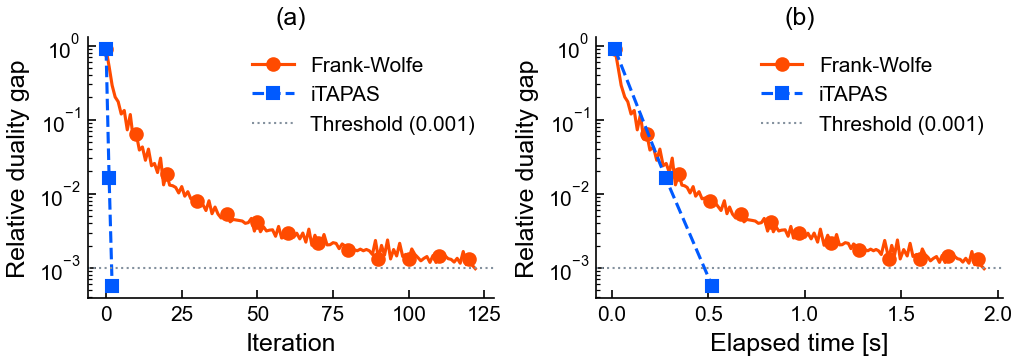

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(7.0, 2.625))

# (a) イテレーション vs rel_gap
ax = axes[0]
ax.semilogy([e['iter'] for e in fw_log], [e['rel_gap'] for e in fw_log],
            '-o', color=COLORS["red"], markevery=10, label='Frank-Wolfe')
ax.semilogy([e['iter'] for e in it_log], [e['rel_gap'] for e in it_log],
            '--s', color=COLORS["blue"], label='iTAPAS')
ax.axhline(y=GAP_THRESHOLD, color=COLORS["gray"], linestyle=':', linewidth=1.0,
           label=f'Threshold ({GAP_THRESHOLD})')
ax.set_xlabel("Iteration")
ax.set_ylabel("Relative duality gap")
ax.set_title("(a)")
ax.legend(loc='upper right')

# (b) 計算時間 vs rel_gap
ax = axes[1]
ax.semilogy([e['time'] for e in fw_log], [e['rel_gap'] for e in fw_log],
            '-o', color=COLORS["red"], markevery=10, label='Frank-Wolfe')
ax.semilogy([e['time'] for e in it_log], [e['rel_gap'] for e in it_log],
            '--s', color=COLORS["blue"], label='iTAPAS')
ax.axhline(y=GAP_THRESHOLD, color=COLORS["gray"], linestyle=':', linewidth=1.0,
           label=f'Threshold ({GAP_THRESHOLD})')
ax.set_xlabel("Elapsed time [s]")
ax.set_ylabel("Relative duality gap")
ax.set_title("(b)")
ax.legend(loc='upper right')

plt.tight_layout()
plt.show()

### 1.2 均衡条件の達成度

均衡状態では、使用経路のコストが最短経路コストに一致する (Wardrop の第一原則)。
各リンクの **縮約コスト** (reduced cost) $rc_a = d_i - d_j + t_a(f_a)$ を計算し、
フローが正のリンクでの縮約コスト分布を比較する。均衡に近いほど $rc_a \approx 0$ となる。

In [5]:
def compute_reduced_costs(net, link_flow, solver_instance):
    """各起点について、フローが正のリンクの縮約コストを計算"""
    link_cost = bpr_cost(link_flow, net.link_fftt, net.link_capacity,
                         net.link_alpha, net.link_beta)
    all_rc = []
    for r in net.origins:
        dist, _ = solver_instance._shortest_path(link_cost, r)
        for e in range(net.num_links):
            if link_flow[e] > 1.0:  # フローが正のリンクのみ
                i = net.link_from[e]
                j = net.link_to[e]
                rc = dist[i] - dist[j] + link_cost[e]
                if rc > 1e-10:
                    all_rc.append(rc)
    return np.array(all_rc)

# 縮約コストの計算
fw_rc = compute_reduced_costs(sf_net, fw_flow, fw_solver)
it_rc = compute_reduced_costs(sf_net, it_flow, itapas_solver)

print("=== 均衡条件の達成度 (フロー正リンクの縮約コスト) ===")
print(f"{'':20s} {'Frank-Wolfe':>15s} {'iTAPAS':>15s}")
print(f"{'正の縮約コスト数':20s} {len(fw_rc):>15d} {len(it_rc):>15d}")
print(f"{'平均':20s} {fw_rc.mean():>15.4f} {it_rc.mean():>15.4f}")
print(f"{'最大':20s} {fw_rc.max():>15.4f} {it_rc.max():>15.4f}")
print(f"{'中央値':20s} {np.median(fw_rc):>15.4f} {np.median(it_rc):>15.4f}")

=== 均衡条件の達成度 (フロー正リンクの縮約コスト) ===
                         Frank-Wolfe          iTAPAS
正の縮約コスト数                        1272            1272
平均                           12.6326         12.6444
最大                           40.4361         40.3077
中央値                          10.3650         10.4806


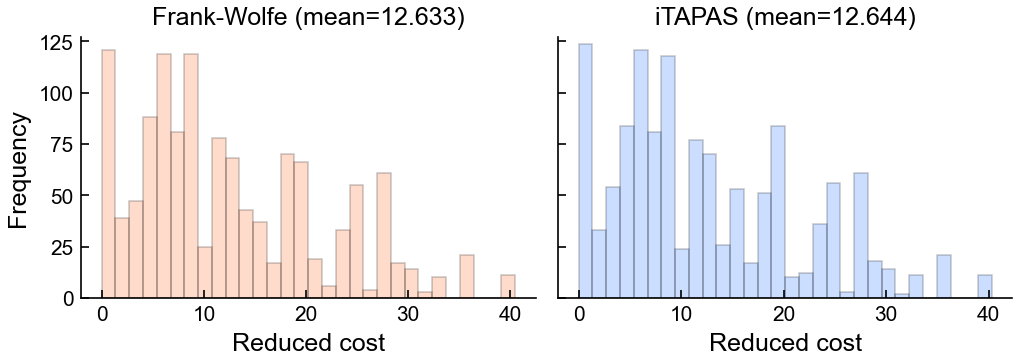

In [6]:
# 縮約コスト分布のヒストグラム
fig, axes = plt.subplots(1, 2, figsize=(7.0, 2.625), sharey=True)

axes[0].hist(fw_rc, bins=30, edgecolor=COLORS["black"], alpha=0.2,
             color=COLORS["red"], linewidth=0.8)
axes[0].set_xlabel("Reduced cost")
axes[0].set_ylabel("Frequency")
axes[0].set_title(f"Frank-Wolfe (mean={fw_rc.mean():.3f})")
axes[0].set_ylim(bottom=0)

axes[1].hist(it_rc, bins=30, edgecolor=COLORS["black"], alpha=0.2,
             color=COLORS["blue"], linewidth=0.8)
axes[1].set_xlabel("Reduced cost")
axes[1].set_title(f"iTAPAS (mean={it_rc.mean():.3f})")
axes[1].set_ylim(bottom=0)

plt.tight_layout()
plt.show()

### 1.3 リンクフローの比較

両手法で得られたリンクフローの散布図。対角線に近いほど解が一致している。

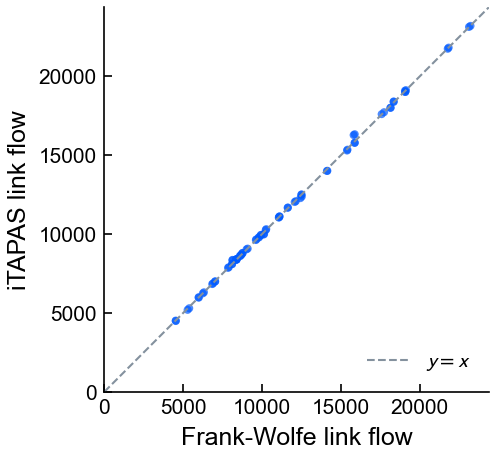

リンクフロー差: 平均=54.5, 最大=470.1, 相対RMSE=0.86%


In [7]:
fig, ax = plt.subplots(figsize=(3.5, 3.5))
ax.scatter(fw_flow, it_flow, s=15, alpha=0.7, color=COLORS["blue"], edgecolors='none')
lim = max(fw_flow.max(), it_flow.max()) * 1.05
ax.plot([0, lim], [0, lim], '--', color=COLORS["gray"], linewidth=1.0, label='$y = x$')
ax.set_xlabel("Frank-Wolfe link flow")
ax.set_ylabel("iTAPAS link flow")
ax.set_xlim(0, lim)
ax.set_ylim(0, lim)
ax.set_aspect('equal')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

# 差の統計
diff = np.abs(fw_flow - it_flow)
print(f"リンクフロー差: 平均={diff.mean():.1f}, 最大={diff.max():.1f}, "
      f"相対RMSE={np.sqrt(np.mean((fw_flow - it_flow)**2)) / np.mean(fw_flow) * 100:.2f}%")

## 2. Grid ネットワークによるスケーラビリティ比較

$N \times N$ の格子ネットワークを動的に生成し、ネットワーク規模が大きくなったときの計算時間を比較する。

**グリッドネットワーク設定:**
- 双方向リンク (各方向に1リンク)
- BPR パラメータ: $\alpha=0.15, \beta=4$
- 容量: 1000 veh/h, 自由走行時間: 1.0 min
- 四隅をゾーンセントロイド (OD起終点) として需要を設定

In [8]:
import os, tempfile
from collections import defaultdict

class GridNetwork:
    """N x N のグリッドネットワークを動的に生成する"""

    def __init__(self, grid_size, num_zones=None, demand_per_od=100):
        """
        Parameters
        ----------
        grid_size : int
            グリッドの1辺のノード数
        num_zones : int or None
            ゾーン数 (None の場合は辺上のノードを使用)
        demand_per_od : float
            各OD対の需要量
        """
        N = grid_size
        self.num_nodes = N * N
        self.node_ids = list(range(self.num_nodes))
        self.node_id_to_idx = {i: i for i in range(self.num_nodes)}
        self.idx_to_node_id = {i: i for i in range(self.num_nodes)}

        # リンク生成 (双方向)
        link_from_list = []
        link_to_list = []
        for r in range(N):
            for c in range(N):
                node = r * N + c
                # 右方向
                if c + 1 < N:
                    link_from_list.append(node)
                    link_to_list.append(node + 1)
                    link_from_list.append(node + 1)
                    link_to_list.append(node)
                # 下方向
                if r + 1 < N:
                    link_from_list.append(node)
                    link_to_list.append(node + N)
                    link_from_list.append(node + N)
                    link_to_list.append(node)

        self.num_links = len(link_from_list)
        self.link_from = np.array(link_from_list, dtype=int)
        self.link_to = np.array(link_to_list, dtype=int)

        # BPR パラメータ
        self.link_capacity = np.full(self.num_links, 1000.0)
        self.link_fftt = np.full(self.num_links, 1.0)
        self.link_alpha = np.full(self.num_links, 0.15)
        self.link_beta = np.full(self.num_links, 4.0)

        # ゾーン (辺上のノードを起終点とする)
        if num_zones is None:
            zones = set()
            for r in range(N):
                for c in range(N):
                    if r == 0 or r == N - 1 or c == 0 or c == N - 1:
                        zones.add(r * N + c)
            zones = sorted(zones)
        else:
            # 均等に配置
            step = max(1, N // int(np.sqrt(num_zones)))
            zones = []
            for r in range(0, N, step):
                for c in range(0, N, step):
                    zones.append(r * N + c)
            zones = zones[:num_zones]

        self.origins = zones

        # 需要: 全ゾーン間 (自己需要除く)
        self.demand = {}
        for o in zones:
            for d in zones:
                if o != d:
                    self.demand[(o, d)] = demand_per_od

        # 隣接リスト
        self.out_links = defaultdict(list)
        self.in_links = defaultdict(list)
        for e in range(self.num_links):
            self.out_links[self.link_from[e]].append(e)
            self.in_links[self.link_to[e]].append(e)

    def summary(self):
        return (f"{int(np.sqrt(self.num_nodes))}x{int(np.sqrt(self.num_nodes))} grid: "
                f"{self.num_nodes}ノード, {self.num_links}リンク, "
                f"{len(self.origins)}ゾーン, {len(self.demand)} OD対")

# テスト
test_grid = GridNetwork(5)
print(test_grid.summary())

5x5 grid: 25ノード, 80リンク, 16ゾーン, 240 OD対


In [9]:
# スケーラビリティ実験
# ゾーン数を固定 (9ゾーン) してネットワーク規模を変化させる
grid_sizes = [5, 10, 15, 20, 25]
NUM_ZONES = 9
SCALE_GAP = 5e-3  # スケーラビリティ実験用の緩い閾値
SCALE_MAX_ITER_FW = 100
SCALE_MAX_ITER_IT = 30
SCALE_TIME_LIMIT = 120  # 各実験の制限時間 (秒)

results_scale = []

for gs in grid_sizes:
    print(f"\n{'='*60}")
    gnet = GridNetwork(gs, num_zones=NUM_ZONES, demand_per_od=200)
    print(gnet.summary())

    # Frank-Wolfe
    fw = FrankWolfe(gnet, bpr_cost, bpr_cost_derivative, bpr_cost_integral)
    t0 = time.time()
    fw_f, fw_l = fw.solve(max_iter=SCALE_MAX_ITER_FW, gap_threshold=SCALE_GAP, verbose=False)
    fw_time = time.time() - t0
    fw_gap = fw_l[-1]['rel_gap']
    fw_iters = fw_l[-1]['iter']
    print(f"  FW:     {fw_time:.2f}s, {fw_iters} iters, rel_gap={fw_gap:.4e}")

    # iTAPAS
    it = ITAPAS(gnet, bpr_cost, bpr_cost_derivative, bpr_cost_integral)
    t0 = time.time()
    it_f, it_l = it.solve(max_iter=SCALE_MAX_ITER_IT, gap_threshold=SCALE_GAP,
                           inner_iterations=5, mu=1e-5,
                           time_limit=SCALE_TIME_LIMIT, verbose=False)
    it_time = time.time() - t0
    it_gap = it_l[-1]['rel_gap']
    it_iters = it_l[-1]['iter']
    print(f"  iTAPAS: {it_time:.2f}s, {it_iters} iters, rel_gap={it_gap:.4e}")

    results_scale.append({
        'grid_size': gs,
        'nodes': gnet.num_nodes,
        'links': gnet.num_links,
        'od_pairs': len(gnet.demand),
        'fw_time': fw_time, 'fw_gap': fw_gap, 'fw_iters': fw_iters,
        'it_time': it_time, 'it_gap': it_gap, 'it_iters': it_iters,
    })

df_scale = pd.DataFrame(results_scale)
print("\n" + "="*60)
print(df_scale.to_string(index=False))


5x5 grid: 25ノード, 80リンク, 9ゾーン, 72 OD対
  FW:     0.12s, 21 iters, rel_gap=4.4082e-03
  iTAPAS: 0.02s, 1 iters, rel_gap=2.2393e-03

10x10 grid: 100ノード, 360リンク, 9ゾーン, 72 OD対


  FW:     0.06s, 9 iters, rel_gap=4.4255e-03


  iTAPAS: 0.12s, 2 iters, rel_gap=3.1282e-04

15x15 grid: 225ノード, 840リンク, 9ゾーン, 72 OD対
  FW:     0.04s, 5 iters, rel_gap=3.5208e-03


  iTAPAS: 0.18s, 2 iters, rel_gap=4.2171e-04

20x20 grid: 400ノード, 1520リンク, 9ゾーン, 72 OD対
  FW:     0.04s, 4 iters, rel_gap=4.2019e-03


  iTAPAS: 0.33s, 2 iters, rel_gap=2.5673e-04

25x25 grid: 625ノード, 2400リンク, 9ゾーン, 72 OD対
  FW:     0.05s, 4 iters, rel_gap=4.0542e-03


  iTAPAS: 0.47s, 2 iters, rel_gap=2.1307e-04

 grid_size  nodes  links  od_pairs  fw_time   fw_gap  fw_iters  it_time   it_gap  it_iters
         5     25     80        72 0.118454 0.004408        21 0.021297 0.002239         1
        10    100    360        72 0.064892 0.004426         9 0.115971 0.000313         2
        15    225    840        72 0.039297 0.003521         5 0.183694 0.000422         2
        20    400   1520        72 0.039922 0.004202         4 0.330368 0.000257         2
        25    625   2400        72 0.052501 0.004054         4 0.466222 0.000213         2


### 2.1 計算時間のスケーラビリティ

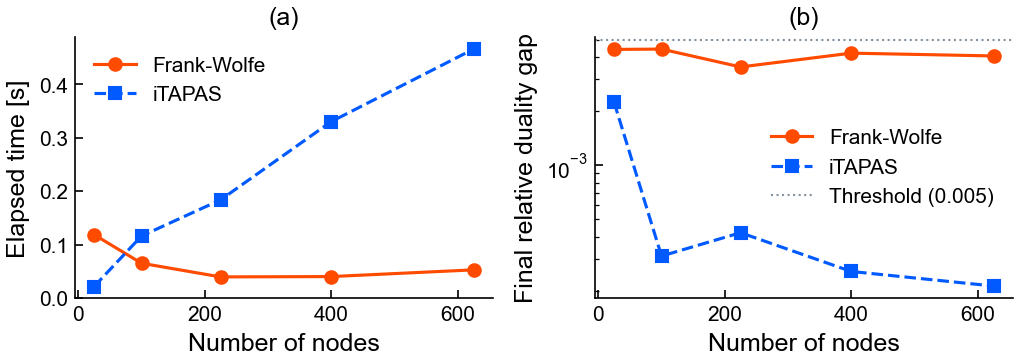

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(7.0, 2.625))

# (a) ノード数 vs 計算時間
ax = axes[0]
ax.plot(df_scale['nodes'], df_scale['fw_time'], '-o', color=COLORS["red"], label='Frank-Wolfe')
ax.plot(df_scale['nodes'], df_scale['it_time'], '--s', color=COLORS["blue"], label='iTAPAS')
ax.set_xlabel("Number of nodes")
ax.set_ylabel("Elapsed time [s]")
ax.set_title("(a)")
ax.set_ylim(bottom=0)
ax.legend(loc='upper left')

# (b) ノード数 vs 最終 rel_gap
ax = axes[1]
ax.semilogy(df_scale['nodes'], df_scale['fw_gap'], '-o', color=COLORS["red"], label='Frank-Wolfe')
ax.semilogy(df_scale['nodes'], df_scale['it_gap'], '--s', color=COLORS["blue"], label='iTAPAS')
ax.axhline(y=SCALE_GAP, color=COLORS["gray"], linestyle=':', linewidth=1.0,
           label=f'Threshold ({SCALE_GAP})')
ax.set_xlabel("Number of nodes")
ax.set_ylabel("Final relative duality gap")
ax.set_title("(b)")
ax.legend(loc='best')

plt.tight_layout()
plt.show()

## 3. まとめ

In [11]:
# サマリテーブル
print("="*70)
print("実験結果サマリ")
print("="*70)
print(f"\n【Sioux Falls (24ノード, 76リンク)】")
print(f"  {'手法':12s} {'時間(s)':>10s} {'イテレーション':>14s} {'rel_gap':>12s}")
print(f"  {'Frank-Wolfe':12s} {fw_log[-1]['time']:>10.2f} {fw_log[-1]['iter']:>14d} {fw_log[-1]['rel_gap']:>12.4e}")
print(f"  {'iTAPAS':12s} {it_log[-1]['time']:>10.2f} {it_log[-1]['iter']:>14d} {it_log[-1]['rel_gap']:>12.4e}")

print(f"\n【Grid ネットワーク スケーラビリティ】")
print(df_scale[['grid_size','nodes','links','fw_time','fw_gap','it_time','it_gap']].rename(
    columns={'grid_size':'Grid', 'nodes':'ノード', 'links':'リンク',
             'fw_time':'FW時間(s)', 'fw_gap':'FW gap',
             'it_time':'iTAPAS時間(s)', 'it_gap':'iTAPAS gap'}
).to_string(index=False))

実験結果サマリ

【Sioux Falls (24ノード, 76リンク)】
  手法                時間(s)        イテレーション      rel_gap
  Frank-Wolfe        1.93            122   9.7385e-04
  iTAPAS             0.52              2   5.6828e-04

【Grid ネットワーク スケーラビリティ】
 Grid  ノード  リンク  FW時間(s)   FW gap  iTAPAS時間(s)  iTAPAS gap
    5   25   80 0.118454 0.004408     0.021297    0.002239
   10  100  360 0.064892 0.004426     0.115971    0.000313
   15  225  840 0.039297 0.003521     0.183694    0.000422
   20  400 1520 0.039922 0.004202     0.330368    0.000257
   25  625 2400 0.052501 0.004054     0.466222    0.000213
